In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.io import loadmat

In [2]:
raw_data = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex6data\ex6data1.mat")
data= pd.DataFrame(raw_data.get('X'),columns=['X1','X2'])
data['y'] = raw_data.get('y')
data.head()

,X1,X2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


In [3]:
def plot_init_data(data,fig,ax):
    positive = data[data['y'].isin([1])]
    negative = data[data['y'].isin([0])]

    ax.scatter(positive['X1'],positive['X2'],s=50,marker='x',label='Positive')
    ax.scatter(negative['X1'],negative['X2'],s=50,marker='o',label='Negative')
    

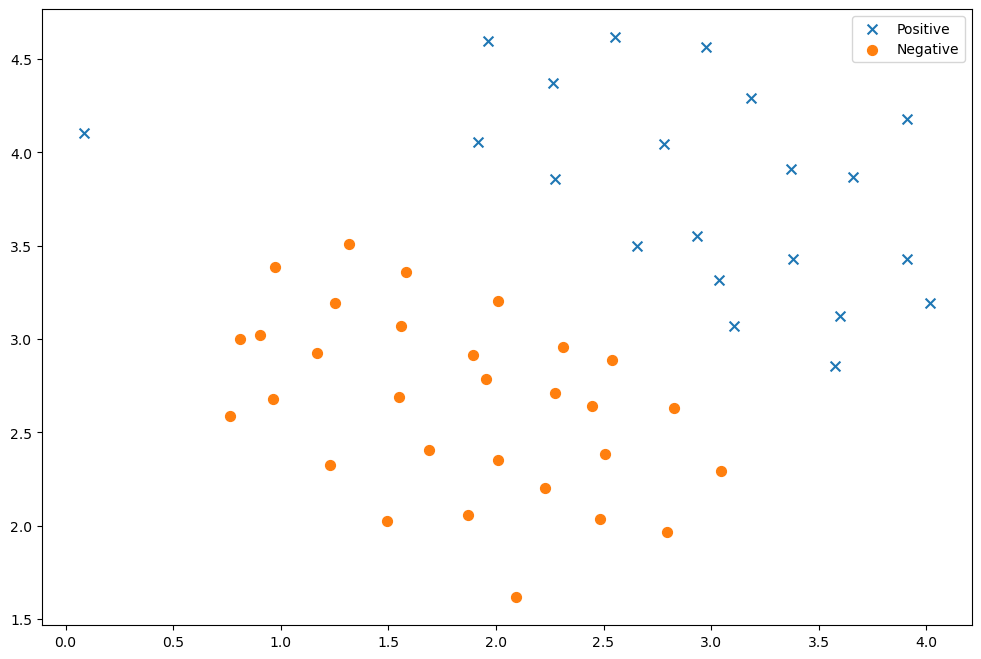

In [4]:
fig,ax = plt.subplots(figsize=(12,8))
plot_init_data(data,fig,ax)
ax.legend()
plt.show()

In [5]:
from sklearn import svm
svc = svm.LinearSVC(C=1,loss='hinge',max_iter = 1000)
svc

,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [6]:
svc.fit(data[['X1','X2']],data['y'])
svc.score(data[['X1','X2']],data['y'])

C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.9803921568627451

In [7]:
def find_decision_boundary(svc,x1min,x1max,x2min,x2max,diff):
    x1 = np.linspace(x1min,x1max,1000)
    x2 = np.linspace(x2min,x2max,1000)

    cordinates = [(x,y) for x in x1 for y in x2]
    x_cord,y_cord=zip(*cordinates)
    c_val = pd.DataFrame({'X1':x_cord,'X2':y_cord})
    c_val['cval'] = svc.decision_function(c_val[['X1','X2']])

    decision = c_val[np.abs(c_val['cval'])<diff]

    return decision.X1,decision.X2

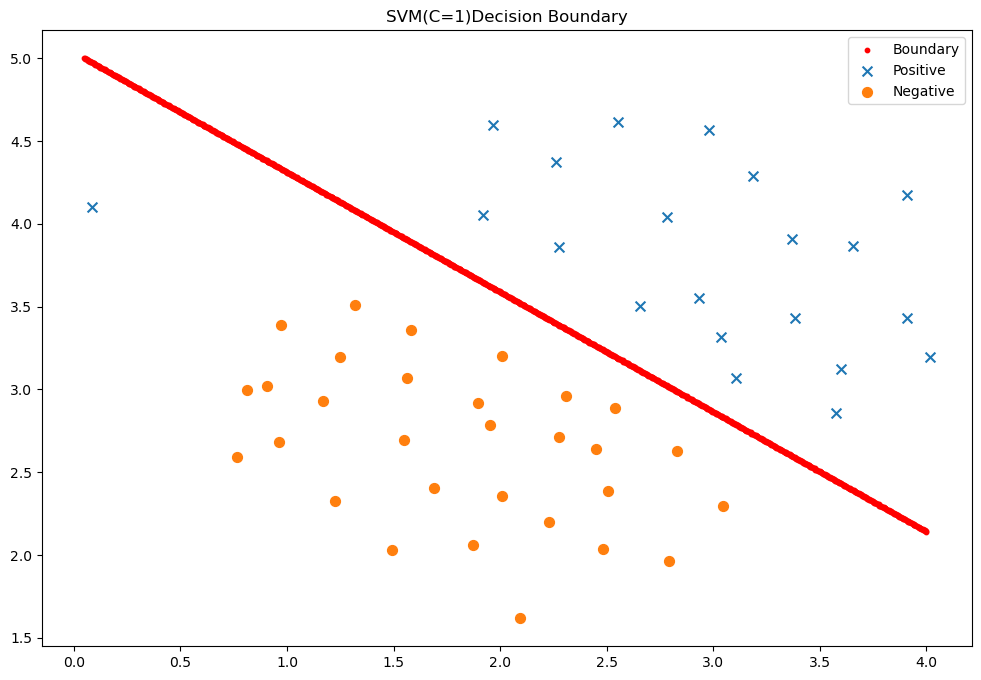

In [8]:
x1,x2 = find_decision_boundary(svc,0,4,1.5,5,2*10**-3)
fig,ax = plt.subplots(figsize=(12,8))
ax.scatter(x1,x2,s=10,c='r',label='Boundary')
plot_init_data(data,fig,ax)
ax.set_title('SVM(C=1)Decision Boundary')
ax.legend()
plt.show()

In [9]:
svc2= svm.LinearSVC(C=100,loss='hinge',max_iter=1000)
svc2.fit(data[['X1','X2']],data['y'])
svc2.score(data[['X1','X2']],data['y'])

C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.9803921568627451

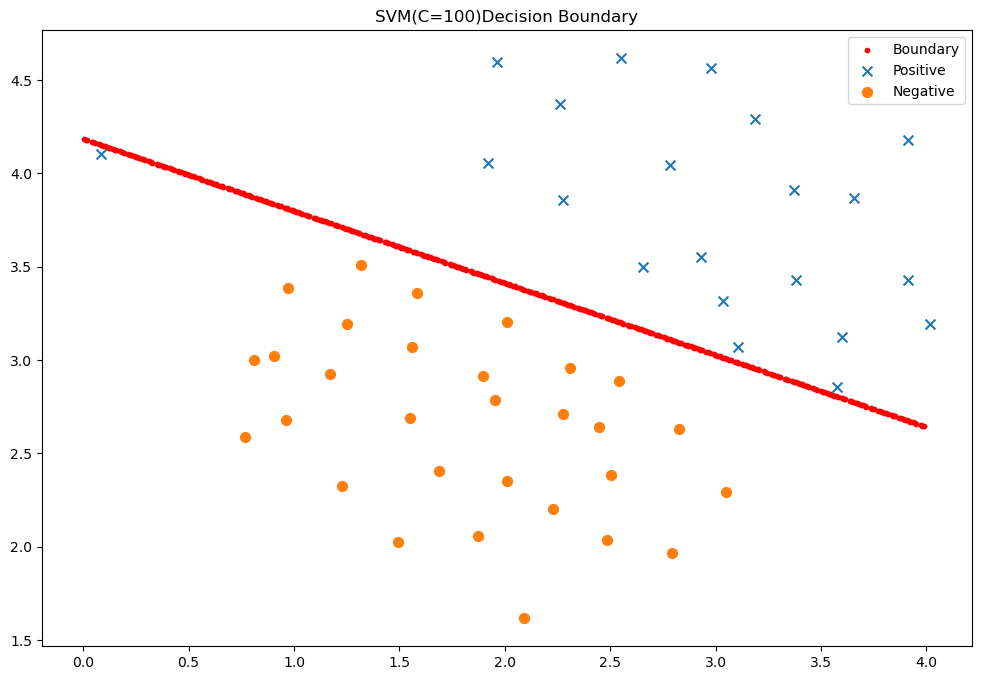

In [10]:
x1,x2 = find_decision_boundary(svc2,0,4,1.5,5,2*10**-3)
fig,ax = plt.subplots(figsize=(12,8))
ax.scatter(x1,x2,s=10,c='r',label='Boundary')
plot_init_data(data,fig,ax)
ax.set_title('SVM(C=100)Decision Boundary')
ax.legend()
plt.show()

In [11]:
def gaussian_kernel(x1,x2,sigma):
    return np.exp(-(np.sum((x1-x2)**2)/(2*(sigma**2))))

In [12]:
x1 = np.array([1.0,2.0,1.0])
x2 = np.array([0.0,4.0,-1.0])
sigma = 2

gaussian_kernel(x1,x2,sigma)

np.float64(0.32465246735834974)

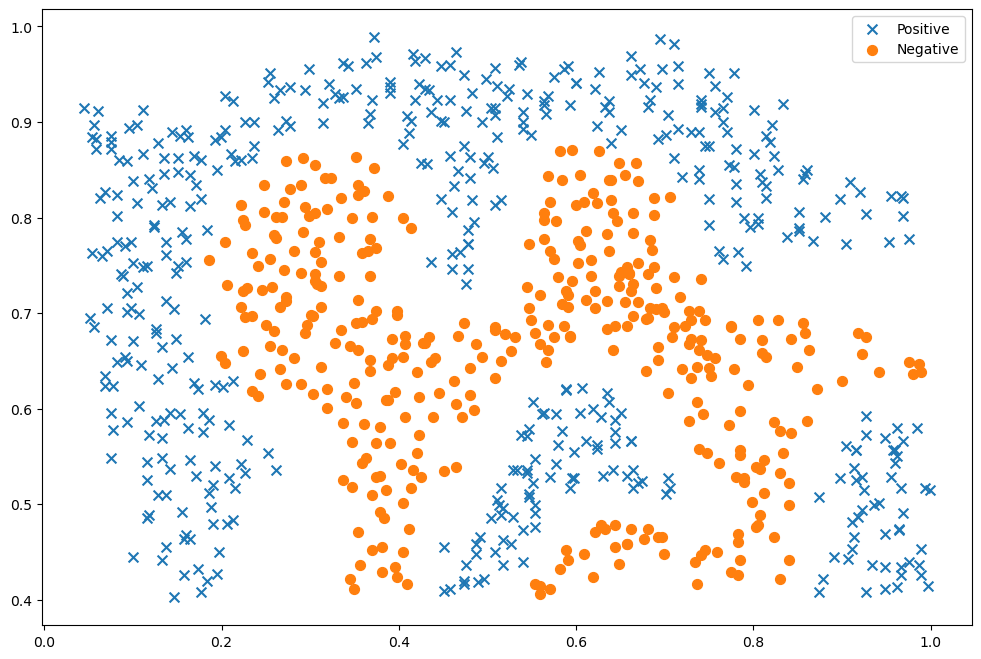

In [13]:
raw_data = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex6data\ex6data2.mat")

data = pd.DataFrame(raw_data['X'],columns=['X1','X2'])
data['y'] = raw_data['y']

fig,ax = plt.subplots(figsize=(12,8))
plot_init_data(data,fig,ax)
ax.legend()
plt.show()

In [14]:
svc = svm.SVC(C=100,gamma=10,probability=True)
svc

,C,100
,kernel,'rbf'
,degree,3
,gamma,10
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [15]:
svc.fit(data[['X1','X2']],data['y'])
svc.score(data[['X1','X2']],data['y'])


0.9698725376593279

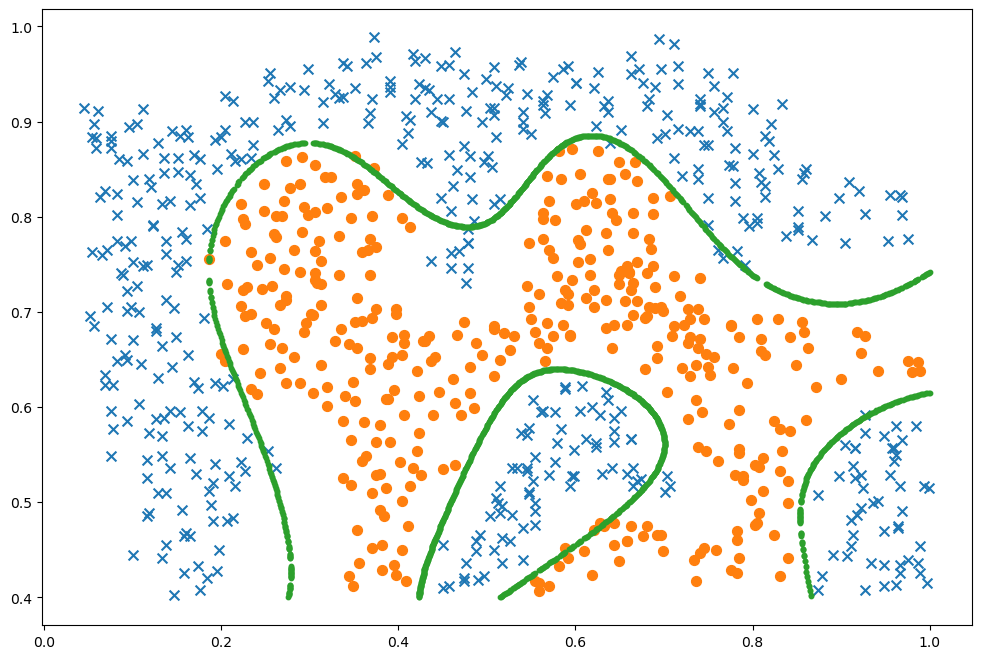

In [16]:
x1,x2 = find_decision_boundary(svc,0,1,0.4,1,0.01)
fig,ax = plt.subplots(figsize=(12,8))
plot_init_data(data,fig,ax)
ax.scatter(x1,x2,s=10)
plt.show()

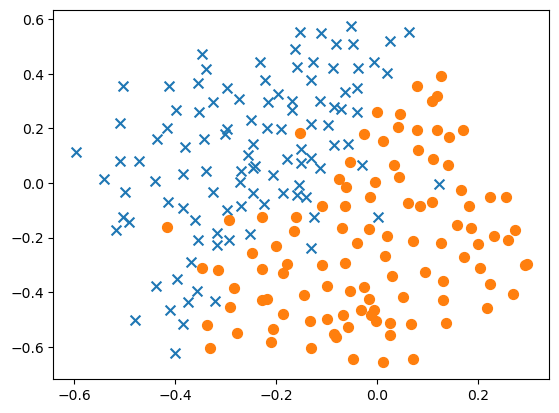

In [24]:
raw_data = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex6data\ex6data3.mat")

X = raw_data['X']
Xval = raw_data['Xval']
y = raw_data['y'].ravel()
yval = raw_data['yval'].ravel()

fig,ax = plt.subplots()
data = pd.DataFrame(raw_data.get('X'),columns = ['X1','X2'])
data['y'] = raw_data.get('y')
plot_init_data(data,fig,ax)
plt.show()


In [26]:
C_values = [0.01,0.03,0.1,0.3,1,3,10,30,100]
gamma_values = [0.01,0.03,0.1,0.3,1,3,10,100]

best_score = 0
best_params = {'C':None,'gamma':None}

for C in C_values:
    for gamma in gamma_values:
        svc= svm.SVC(C=C,gamma=gamma)
        svc.fit(X,y)
        score = svc.score(Xval,yval)

        if score>best_score:
            best_score=score
            best_params['C'] = C
            best_params['gamma'] = gamma

best_score,best_params

(0.965, {'C': 0.3, 'gamma': 100})

C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


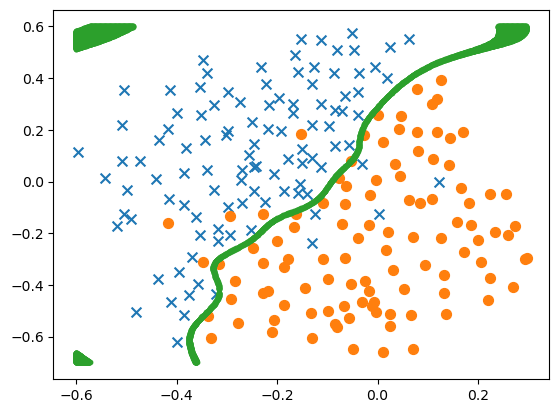

In [27]:
svc = svm.SVC(C=best_params['C'],gamma=best_params['gamma'])
svc.fit(X,y)

x1,x2 = find_decision_boundary(svc,-0.6,0.3,-0.7,0.6,0.005)
fig,ax=plt.subplots()
plot_init_data(data,fig,ax)
ax.scatter(x1,x2,s=10)
plt.show()

In [28]:
spam_train = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex6data\spamTrain.mat")
spam_test = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex6data\spamTest.mat")

spam_train

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:27:25 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(4000, 1899), dtype=uint8),
 'y': array([[1],
        [1],
        [0],
        ...,
        [1],
        [0],
        [0]], shape=(4000, 1), dtype=uint8)}

In [29]:
X = spam_train['X']
Xtest = spam_test['Xtest']
y = spam_train['y'].ravel()
ytest = spam_test['ytest'].ravel()

X.shape,y.shape,Xtest.shape,ytest.shape

((4000, 1899), (4000,), (1000, 1899), (1000,))

In [30]:
svc = svm.SVC()
svc.fit(X,y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
print('Training accuracy = {0}%'.format(np.round(svc.score(X,y)*100,2)))
print('Test accuracy = {0}%'.format(np.round(svc.score(Xtest,ytest)*100,2)))

Training accuracy = 99.32%
Test accuracy = 98.7%


In [33]:
kw = np.eye(1899)
kw[:3,:]
spam_val = pd.DataFrame({'idx':range(1899)})

In [35]:
spam_val['isspam'] = svc.decision_function(kw)

In [36]:
spam_val['isspam'].describe()

count    1899.000000
mean       -0.110039
std         0.049094
min        -0.428396
25%        -0.131213
50%        -0.111985
75%        -0.091973
max         0.396286
Name: isspam, dtype: float64

In [39]:
decision = spam_val[spam_val['isspam']>0]
decision

,idx,isspam
155,155,0.095529
173,173,0.066666
297,297,0.396286
351,351,0.023785
382,382,0.030317
476,476,0.042474
478,478,0.057344
529,529,0.060692
537,537,0.008558
680,680,0.109643


In [40]:
path = r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex6data\vocab.txt"
voc = pd.read_csv(path,header=None,names=['idx','voc'],sep='\t')
voc.head()

,idx,voc
0,1,aa
1,2,ab
2,3,abil
3,4,abl
4,5,about


In [41]:
spamvoc = voc.loc[list(decision['idx'])]
spamvoc

,idx,voc
155,156,basenumb
173,174,below
297,298,click
351,352,contact
382,383,credit
476,477,dollar
478,479,dollarnumb
529,530,email
537,538,encod
680,681,free
